# Bank Telemarketing Prediction Models

This notebook trains three machine learning models on the bank-full-transformed dataset to predict the target variable 'y' (whether a customer will subscribe to a term deposit).

## 1. Load Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

## 2. Load and Inspect Dataset

In [2]:
df = pd.read_csv('data_previous_final.csv')

print("Dataset shape:", df.shape)
print("\nSummary statistics:")
print(df.describe())
print("\nClass distribution for target 'y':")
print(df['y'].value_counts())
print("\nClass balance:")
print(df['y'].value_counts(normalize=True))

Dataset shape: (8251, 34)

Summary statistics:
               day        pdays     previous  balance_log  month_encoded  \
count  8251.000000  8251.000000  8251.000000  8251.000000    8251.000000   
mean     14.288692   224.539813     1.238856     9.139177       4.832263   
std       7.917991   115.306799     0.546092     0.211951       3.097249   
min       1.000000     1.000000     0.693147     8.722091       0.000000   
25%       7.000000   133.000000     0.693147     9.010425       3.000000   
50%      14.000000   194.000000     1.098612     9.062304       4.000000   
75%      20.000000   327.000000     1.609438     9.186611       7.000000   
max      31.000000   871.000000     4.077537    11.398917      11.000000   

       campaign_log  
count   8251.000000  
mean       1.025705  
std        0.397471  
min        0.693147  
25%        0.693147  
50%        1.098612  
75%        1.098612  
max        2.833213  

Class distribution for target 'y':
y
False    6348
True     1903
Name

## 3. Preprocess Features and Target

In [3]:
X = df.drop('y', axis=1)
y = df['y'].astype(int) 

bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

cat_cols = X.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))
print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (6600, 33)
Test set shape: (1651, 33)
Training target distribution:
y
0    0.769394
1    0.230606
Name: proportion, dtype: float64
Test target distribution:
y
0    0.769231
1    0.230769
Name: proportion, dtype: float64


## 4. Train Logistic Regression

In [4]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test, lr_pred_proba)
lr_report = classification_report(y_test, lr_pred, output_dict=True)

print("Logistic Regression Results:")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"ROC AUC: {lr_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Results:
Accuracy: 0.8365
ROC AUC: 0.8188

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1270
           1       0.71      0.50      0.58       381

    accuracy                           0.84      1651
   macro avg       0.78      0.72      0.74      1651
weighted avg       0.83      0.84      0.83      1651



c:\Users\Lenna\Documents\Repos\bank-telemarketing-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5. Train XGBoost

In [5]:
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_pred_proba)
xgb_report = classification_report(y_test, xgb_pred, output_dict=True)

print("XGBoost Results:")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"ROC AUC: {xgb_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

xgb_feature_importance = xgb_model.feature_importances_

XGBoost Results:
Accuracy: 0.8177
ROC AUC: 0.8324

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.88      1270
           1       0.62      0.55      0.58       381

    accuracy                           0.82      1651
   macro avg       0.74      0.72      0.73      1651
weighted avg       0.81      0.82      0.81      1651



## 6. Train Random Forest

In [6]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_pred_proba)
rf_report = classification_report(y_test, rf_pred, output_dict=True)

print("Random Forest Results:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"ROC AUC: {rf_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

rf_feature_importance = rf_model.feature_importances_

Random Forest Results:
Accuracy: 0.8322
ROC AUC: 0.8511

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.90      1270
           1       0.69      0.50      0.58       381

    accuracy                           0.83      1651
   macro avg       0.78      0.71      0.74      1651
weighted avg       0.82      0.83      0.82      1651



## 7. Evaluate Models

Models Comparison:
                 Model  Accuracy   ROC AUC  Precision (Class 1)  \
0  Logistic Regression  0.836463  0.818848             0.706320   
1              XGBoost  0.817686  0.832426             0.618343   
2        Random Forest  0.832223  0.851102             0.689781   

   Recall (Class 1)  F1-Score (Class 1)  
0          0.498688            0.584615  
1          0.548556            0.581363  
2          0.496063            0.577099  


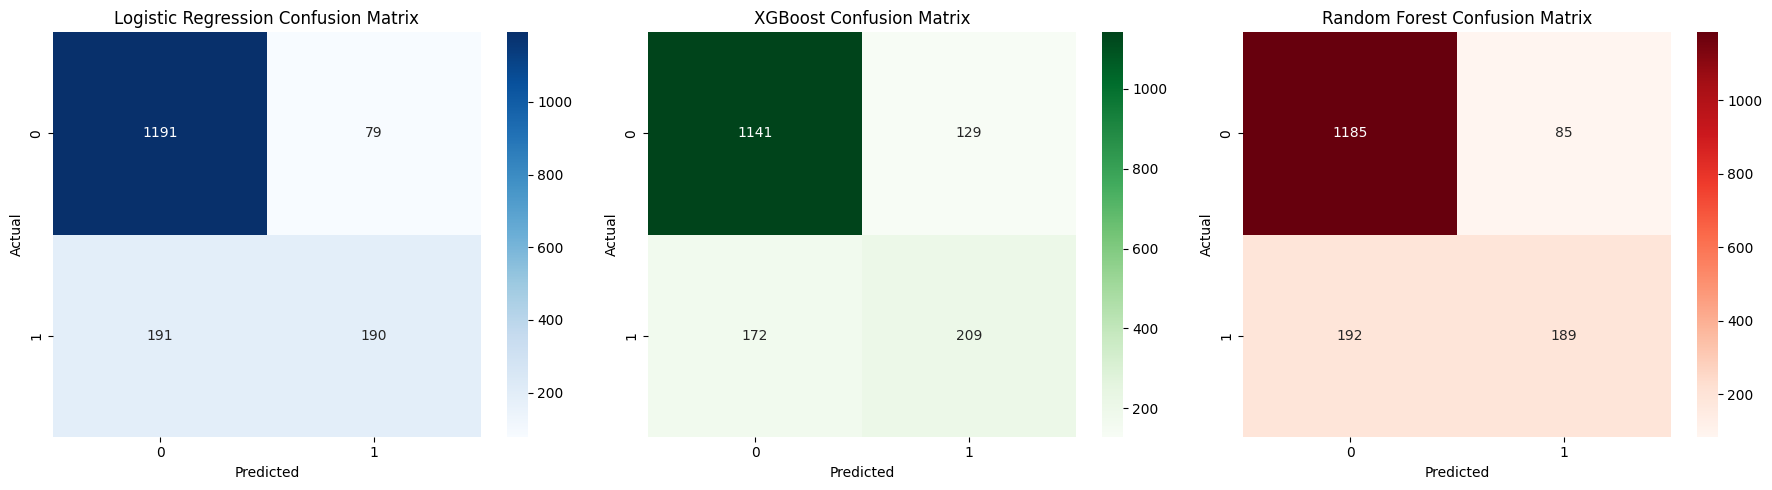

In [7]:
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest'],
    'Accuracy': [lr_accuracy, xgb_accuracy, rf_accuracy],
    'ROC AUC': [lr_roc_auc, xgb_roc_auc, rf_roc_auc],
    'Precision (Class 1)': [lr_report['1']['precision'], xgb_report['1']['precision'], rf_report['1']['precision']],
    'Recall (Class 1)': [lr_report['1']['recall'], xgb_report['1']['recall'], rf_report['1']['recall']],
    'F1-Score (Class 1)': [lr_report['1']['f1-score'], xgb_report['1']['f1-score'], rf_report['1']['f1-score']]
})

print("Models Comparison:")
print(models_comparison)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[2], cmap='Reds')
axes[2].set_title('Random Forest Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 8. Visualize Results

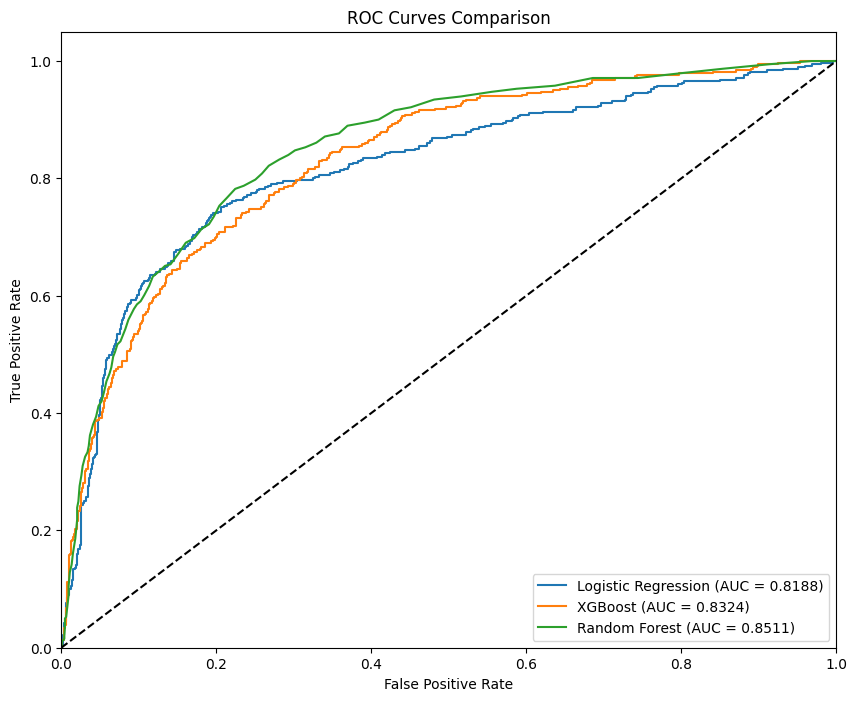

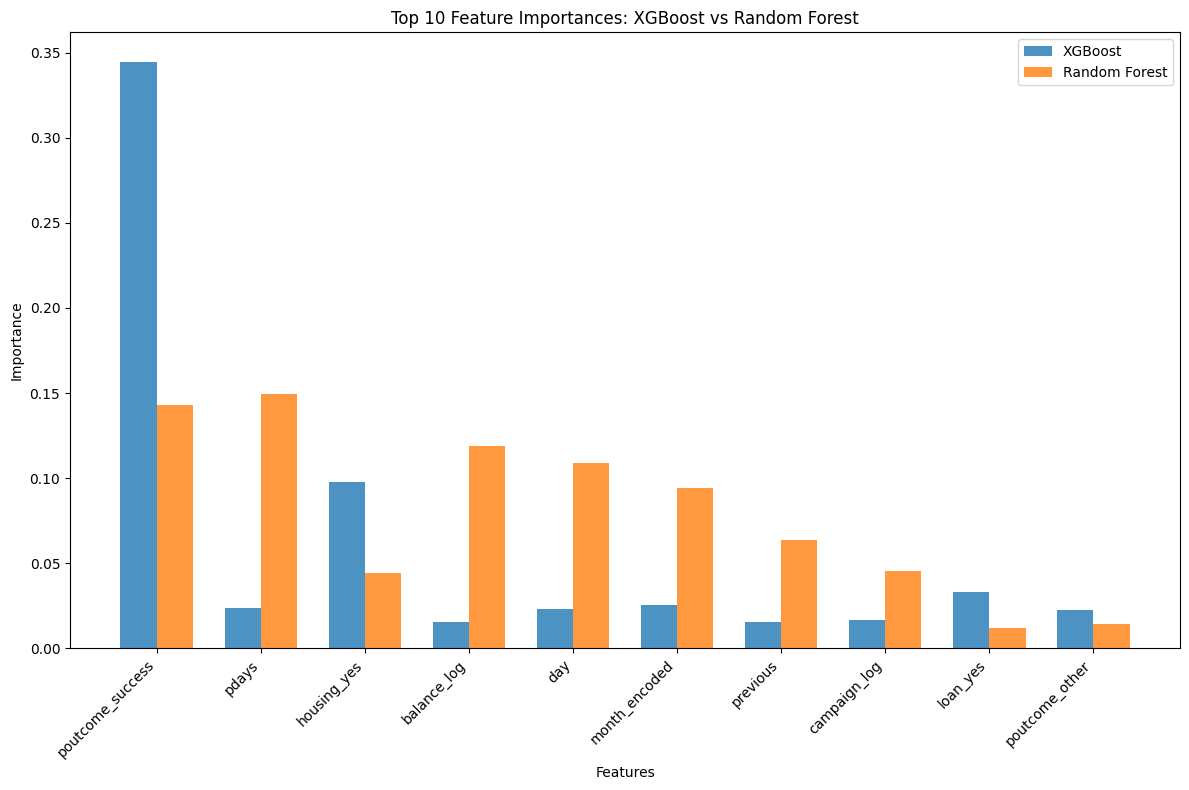

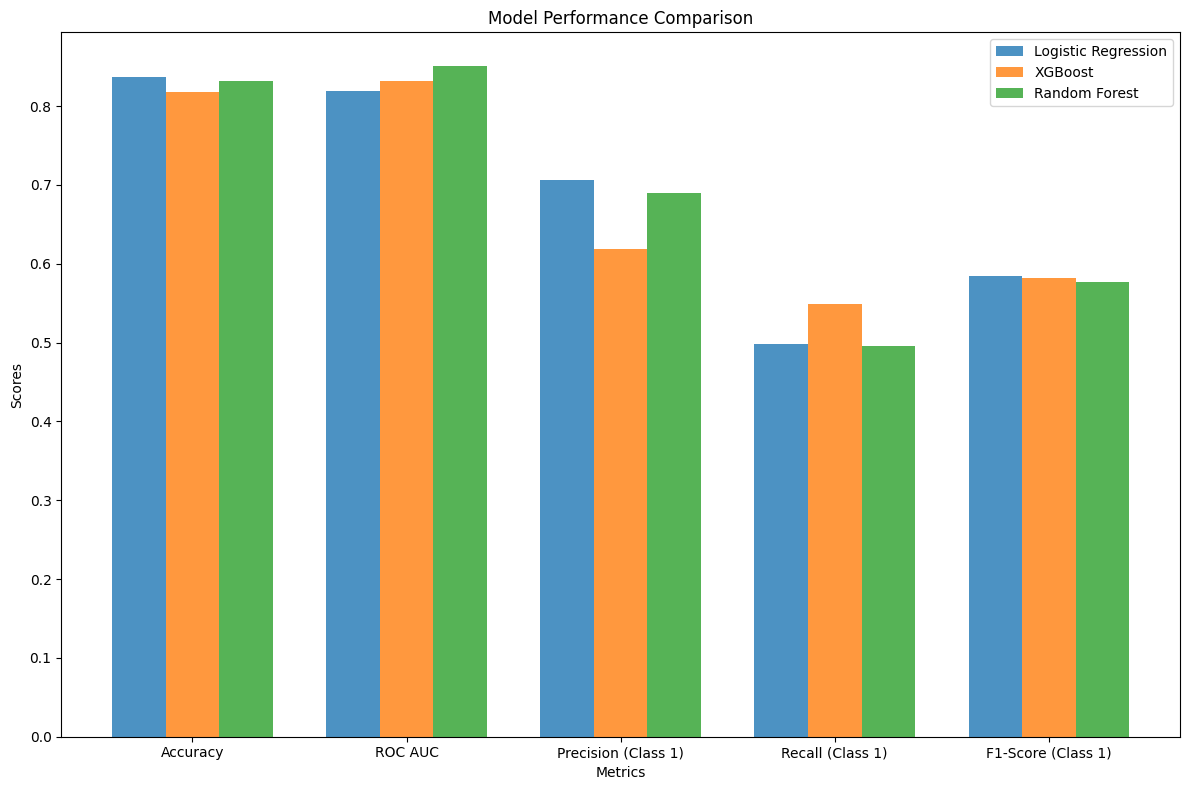

In [8]:
plt.figure(figsize=(10, 8))

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_roc_auc:.4f})')

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.show()

feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'XGBoost': xgb_feature_importance,
    'Random Forest': rf_feature_importance
})

importance_df['Average'] = (importance_df['XGBoost'] + importance_df['Random Forest']) / 2
top_features = importance_df.nlargest(10, 'Average')

plt.figure(figsize=(12, 8))
x = np.arange(len(top_features))
width = 0.35

plt.bar(x - width/2, top_features['XGBoost'], width, label='XGBoost', alpha=0.8)
plt.bar(x + width/2, top_features['Random Forest'], width, label='Random Forest', alpha=0.8)

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Top 10 Feature Importances: XGBoost vs Random Forest')
plt.xticks(x, top_features['Feature'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

metrics = ['Accuracy', 'ROC AUC', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 8))
rects1 = ax.bar(x - width, models_comparison.loc[0, metrics], width, label='Logistic Regression', alpha=0.8)
rects2 = ax.bar(x, models_comparison.loc[1, metrics], width, label='XGBoost', alpha=0.8)
rects3 = ax.bar(x + width, models_comparison.loc[2, metrics], width, label='Random Forest', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.show()